<div style="text-align: center;">

# COSC 3P96 - Gradient Descent as Search for Facial Attribute Prediction

### Lauren Corbeil | Student ID: 7698699 | Email: wf22dy@brocku.ca
### Holly Young | Student ID: 7492895 | Email: hy21zt@brocku.ca
### Skyler Serwa | Student ID: 1111111 | Email: ss22tp@brocku.ca

### Linear and logistic regression implemented using gradient descent to predict facial attributes, with experiments analyzing learning rates, convergence, and loss behavior.

In [1]:
# use pip install -r requirements.txt

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import CelebA

# 1.

<div style="text-align: center;">

## Data Loading and Cleaning

<div style="text-align: left;">

- Download the CelebA dataset using torchvision
- Read and parse the attribute file to extract attribute names and data samples
- Select a single attribute as the target variable
- Extract labels for the selected attribute and convert values from {-1, 1} to {0, 1}
- Use a subset of the data and assign placeholder features for each sample

In [ ]:
def download_dataset(download_path = "CelebA_dataset"):

    print("Please download the dataset manually (the download limit has been reached in the google drive for this dataset).")

    #
    # TRY TO UNCOMMENT THIS CODE AND DOWNLOAD FROM HERE FIRST:
    #

    # CelebA(root = download_path, split = "train", download = True)
    # print("The dataset was downloaded.")

def load_data(file_path, image_path, attribute_name, max_samples = 5000):
    X = []
    y = []

    with open(file_path, 'r') as file:
        data = file.readlines()

    attribute_names = data[1].split()
    attribute_index = attribute_names.index(attribute_name)

    image_data = data[2:]

    for i, d in enumerate(image_data):
        if i >= max_samples:
            break
        parts = d.split()

        label = int(parts[attribute_index + 1])
        image_name = parts[0]

        # Change -1 to 0
        if label == -1:
            label = 0

        # Reisizing and recoloring images for analysis.
        img = os.path.join(image_path, image_name)
        img = cv2.imread(img)
        img = cv2.resize(img, (64, 64))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        y.append(label)
        X.append(img)

    return X, y

# Use the code we just made

path = os.path.join(os.getcwd(), "CelebA_dataset")
download_dataset(path)
attribute_file = os.path.join(path, "celeba", "list_attr_celeba.txt")
image_folder = os.path.join(path, "celeba", "img_align_celeba")

X, y = load_data(attribute_file, image_folder, "Smiling")

print("Sample images: ", len(X))
print("First 10 labels:", y[:10])


Please download the dataset manually (the download limit has been reached in the google drive for this dataset).
Sample images:  5000
First 10 labels: [1, 1, 0, 0, 0, 0, 0, 0, 1, 0]


# 2.

<div style="text-align: center;">

## Split and Standardize Data

<div style="text-align: left;">

- Filler
- Filler
- FIller

In [ ]:
def train_test_split(X, y, test_size = 0.2):
    n = len(X)

    #shuffle
    indices = np.random.permutation(n)

    #get split point
    split = int (n * (1 - test_size))
    train_index = indices[:split]
    test_index = indices[split:]

    return X.iloc[train_index], X.iloc[test_index], y.iloc[train_index], y.iloc[test_index]

X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_encoded, y_regression)
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(X_encoded, y_classification)

def std_train_test(X_train, X_test):
    # get mean and std deviation from training set 
    mean = X_train.mean()
    std_deviation = X_train.std() + 1e-8 #add epsilon to ensure it doesnt break

    # Apply formula to train and test
    return (X_train - mean) / std_deviation, (X_test - mean) / std_deviation

X_train_reg_std, X_test_reg_std = std_train_test(X_train_regression, X_test_regression)
X_train_clf_std, X_test_clf_std = std_train_test(X_train_classification, X_test_classification)

# 3.

<div style="text-align: center;">

## Linear Regression Model

<div style="text-align: left;">

- Initialize Parameters (bias and weights)
- Run Gradient Descent loop to update weights
- Keep track of the loss with MSE to ensure convergence
- Normalize Features (scale pixel values and turn images to vectors)
- Apply 0.5 threshold to classify results
- Generate confusion matrix and MSE plot

In [ ]:
# Pandas object to numpy array
X_train_input = X_train_reg_std.to_numpy()
X_test_input = X_test_reg_std.to_numpy()

y_training_regression = y_train_regression.to_numpy()
y_test_targets = y_test_regression.to_numpy()

# dimensions of array
n, d = X_train_input.shape

# slopes and intercepts
m = np.zeros(d)
b = 0.0

# linear model: y_hat = X @ m + b (matrix multiplication)
def predict_linear(X, m, b):
    return X @ m +b

# MSE loss: L = (1/n) * sum((y_hat - y)^2)
def mse_loss(y_hat, y):
    return np.mean((y_hat - y) ** 2)

# Computer gradients of MSE loss with respect to m and b
# dL/dm = (2/n) * X.T @ (y_hat - y)
# dL/db = (2/n) * sum(y_hat - y)
def linear_gradients(X, y, m, b):
    n = X.shape[0]
    y_hat = predict_linear(X, m, b)
    error = y_hat - y

    #gradient for weights
    weights = (2/n) * (X.T @ error)

    #gradient for bias
    bias = (2/n) * np.sum(error)

    return weights, bias

# Training linear regression

def linear_gradient_descent(X, y, learning_rate=0.05, epochs=500):
    n, d = X.shape

    # weight and bias 
    m = np.zeros(d)
    b = 0.0
    history = []

    for t in range(epochs):
        y_hat = predict_linear(X, m, b)
        loss = mse_loss(y_hat, y)
        history.append(loss)

        #compute gradients
        weight, bias = linear_gradients(X, y, m, b)

        #update params
        m = m - learning_rate * weight
        b = b - learning_rate * bias

    return m, b, np.array(history)

m_learning_rate, b_learning_rate, mse_history = linear_gradient_descent(X_train_input, y_training_regression, learning_rate=0.05, epochs=500)
print("Mean Squared Error (Final): ", mse_history[-1])
plt.figure()
plt.plot(mse_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Epochs")
plt.show()

y_hat_test = predict_linear(X_test_input, m_learning_rate, b_learning_rate)
test_mse = mse_loss(y_hat_test, y_test_targets)
print("Test Mean Squared Error: ", test_mse)

# Test multiple learning rates to observe convergence

learning_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure()

for r in learning_rates:
    # Train with each learning rate and plot convergence
    m_r, b_r, hist = linear_gradient_descent(X_train_input, y_training_regression, learning_rate=r, epochs=500)
    plt.plot(hist, label=f"lr={r}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training MSE vs Epochs for Different Learning Rates")
plt.legend()
plt.show()

Loading data...
Training Iteration 0 MSE = 0.4812
Training Iteration 2 MSE = 0.32463115404137116
Training Iteration 4 MSE = 0.28009136682557306
Training Iteration 6 MSE = 0.26688471002672315
Training Iteration 8 MSE = 0.2624642196334296
Training Iteration 10 MSE = 0.260528920759343
Training Iteration 12 MSE = 0.2593168035851908
Training Iteration 14 MSE = 0.258334063330774
Training Iteration 16 MSE = 0.25744129720207953
Training Iteration 18 MSE = 0.25659819755981506
Training Iteration 20 MSE = 0.25579221864067037
Training Iteration 22 MSE = 0.2550186428036061
Training Iteration 24 MSE = 0.2542750072317697


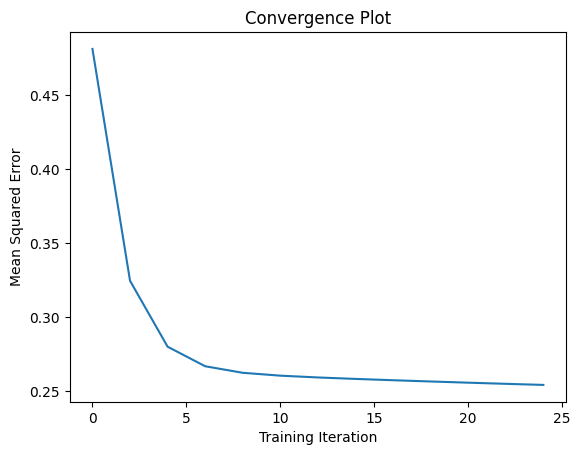

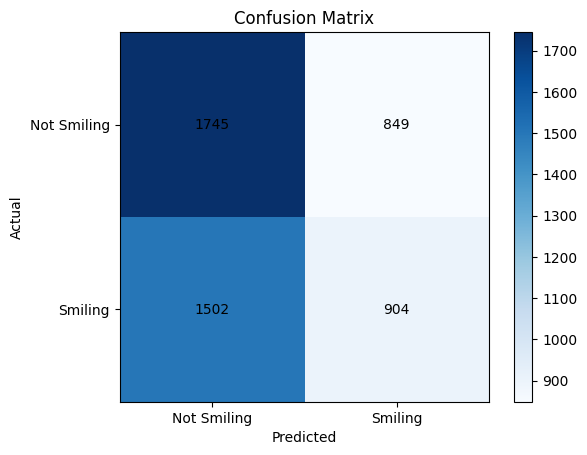

In [ ]:
# ## Linear Regression Model ##

# def train_model(b, w, learning_rate, epochs, n):
#     # Gradient descent loop.
#     for i in range(epochs):
#         y_pred = b + X @ w
#         error = y_pred - y

#         b -= learning_rate * (1/n) * np.sum(error)
#         w -= learning_rate * (1/n) * (X.T @ error)

#         if i % 2 == 0:
#             mse = (1/n) * np.sum((error) ** 2)
#             print(f"Training Iteration {i} MSE = {mse}")
#             iterations.append(i)
#             graphpoints.append(mse)
#     return b, w

# def confusion_matrix(y_true, y_pred):
#     TP = np.sum((y_true == 1) & (y_pred == 1))
#     TN = np.sum((y_true == 0) & (y_pred == 0))
#     FP = np.sum((y_true == 0) & (y_pred == 1))
#     FN = np.sum((y_true == 1) & (y_pred == 0))
#     return np.array([[TN, FP], [FN, TP]])

# # Sorting out file paths and loading data.
# print("Loading data...")

# base_path = os.path.join(os.getcwd(), "CelebA_dataset")
# attribute_file = os.path.join(base_path, "celeba", "list_attr_celeba.txt")
# image_folder = os.path.join(base_path, "celeba", "img_align_celeba")

# X, y = load_data(attribute_file, image_folder, "Smiling")

# # Converting data to numpy arrays and normalizing image pixels.
# X = np.array(X) / 255.0
# X = X.reshape(len(X), -1)
# y = np.array(y)

# # Initializing the training parameters and training the model.
# b = 0
# w = np.zeros(X.shape[1])
# learning_rate = 0.0001
# epochs = 25
# n = X.shape[0]
# iterations = []
# graphpoints = []

# b, w = train_model(b, w, learning_rate, epochs, n)

# # Displaying the convergence plot.
# plt.plot(iterations, graphpoints)
# plt.title(f"Convergence Plot")
# plt.xlabel("Training Iteration")
# plt.ylabel("Mean Squared Error")
# plt.show()

# # Creating the confusion matrix.
# y_pred = ((b + X @ w) >= 0.5).astype(int)
# cm = confusion_matrix(y, y_pred)

# # Displaying the confusion matrix.
# plt.imshow(cm, cmap = 'Blues')

# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")

# plt.xticks([0, 1], ["Not Smiling", "Smiling"])
# plt.yticks([0, 1], ["Not Smiling", "Smiling"])

# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, cm[i, j], ha = 'center', va = 'center')

# plt.colorbar()
# plt.show()

# 3.

<div style="text-align: center;">

## Logistic Regression + Optimization with Gradient Descent

<div style="text-align: left;">

- Filler
- Filler
- Filler

In [ ]:
#Initialize Variables

# Pandas object to numpy array
X_train_classification_input = X_train_clf_std.to_numpy()
X_test_classification_input = X_test_clf_std.to_numpy()
y_train_classification_targets = y_train_classification.to_numpy()
y_test_classification_targets = y_test_classification.to_numpy()

n_clf, d_clf = X_train_classification_input.shape

#weight and bias
m_classification = np.zeros(d_clf)
b_classification = 0.0

print("X_train_classification_input: ", X_train_classification_input.shape)
print("y_train_classification_targets: ", y_train_classification_targets.shape)



# Logistic Regression Functions

# Sigmoid: sigma(z) = 1 / (1 + e^-z), outputs probability in [0, 1]
def sigmoid(z):
    #prevent overflow
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def predict_positive_class_probability(X, w, b):
    return sigmoid(X @ w + b)

# cross entropy loss for binary classification
# L = -(1/n) * sum(y*log(y_hat) + (1-y)*log(1-y_hat))
def log_loss(y_hat, y):
    epsilon = 1e-12
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))



# Gradient Computation for Logistic Regression

# cross-entropy loss gradient for logistic regression
# dL/dw = (1/n) * X.T @ (y_hat - y)
# dL/db = (1/n) * sum(y_hat - y)
def logistic_gradients(X, y, w, b):
    n = X.shape[0]
    y_hat = predict_positive_class_probability(X, w, b)
    error = y_hat - y

    grad_w = (1/n) * (X.T @ error)
    grad_b = (1/n) * np.sum(error)

    return grad_w, grad_b

# gradient descent loop
def logistic_gradient_descent(X, y, learning_rate=0.1, epochs=500):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    history = []

    for t in range(epochs):
        y_hat = predict_positive_class_probability(X, w, b)
        loss = log_loss(y_hat, y)
        history.append(loss)

        grad_w, grad_b = logistic_gradients(X, y, w, b)
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b

    return w, b, np.array(history)

w_lr, b_lr, loss_history = logistic_gradient_descent(
    X_train_classification_input, y_train_classification_targets, learning_rate=0.1, epochs=2000
)

print("Final Training Log-Loss:", loss_history[-1])

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Log-Loss")
plt.title("Log-Loss vs Epochs (Logistic Regression)")
plt.show()

# 4.

<div style="text-align: center;">

## Calculate Accuracy

<div style="text-align: left;">

- Filler
- Filler
- Filler

In [ ]:
def predict_class_logistic(X, w, b):
    probs = predict_positive_class_probability(X, w, b)
    return (probs >= 0.5).astype(int)

y_test_pred = predict_class_logistic(X_test_classification_input, w_lr, b_lr)

accuracy = np.mean(y_test_pred == y_test_classification_targets)

print("Test Accuracy:", accuracy)

# Learning rate comparison for logistic regression
learning_rates_lr = [0.01, 0.05, 0.1, 0.2]
plt.figure()
for lr in learning_rates_lr:
    w, b, hist = logistic_gradient_descent(X_train_classification_input, y_train_classification_targets, learning_rate=lr, epochs=500)
    plt.plot(hist, label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Log-Loss')
plt.title('Logistic Regression: Learning Rate Convergence Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def confusion_matrix_binary(y_labels, y_predicted_labels):
    true_positive = np.sum((y_labels == 1) & (y_predicted_labels == 1))
    true_negative = np.sum((y_labels == 0) & (y_predicted_labels == 0))
    false_positive = np.sum((y_labels == 0) & (y_predicted_labels == 1))
    false_negative = np.sum((y_labels == 1) & (y_predicted_labels == 0))
    return true_positive, true_negative, false_positive, false_negative

true_positive, true_negative, false_positive, false_negative = confusion_matrix_binary(y_test_classification_targets, y_test_pred)
accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
precision = true_positive / (true_positive + false_positive + 1e-12)
recall = true_positive / (true_positive + false_negative + 1e-12)
f1 = 2 * precision * recall / (precision + recall)

print("Confusion Matrix:")
print("True Positive: ", true_positive, "True Negative: ", true_negative, "False Positive: ", false_positive, "False Negative: ", false_negative)
print()
print("Metrics: ")
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)

cm = np.array([[true_negative, false_positive],
               [false_negative, true_positive]])

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.yticks([0, 1], ['No (0)', 'Yes (1)'])

max_val = cm.max()
for i in range(2):
    for j in range(2):
        text_color = 'black' if cm[i, j] < max_val / 2 else 'white'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                 color=text_color, fontsize=14, fontweight='bold')

plt.colorbar(label='Count')
plt.show()